In [2]:
import os

# change directory one up 
os.chdir('..')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_and_concat_shift_files(folder_path, prefix, column_name, pos=-1):
    """
    Load CSV files from folder_path that start with prefix, sort them based on the number
    at the end of the filename, add a column with that number, and concatenate all into a single DataFrame.
    
    Args:
        folder_path (str): Path to the folder containing the CSV files.
        prefix (str): Prefix of the files to include.
        column_name (str): Name of the new column to store the shift number.
        idx (int): Index of the parameter to shift (default: -1 for last parameter).

    Returns:
        pd.DataFrame: Concatenated DataFrame of all relevant CSVs with shift column added.
    """
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    # sort files by the number at the end
    shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[pos].replace('.csv','')))
    for idx, f in enumerate(shift_files):
        df = pd.read_csv(os.path.join(folder_path, f))
        df[column_name] = float(f.split('_')[-1].replace('.csv',''))
        if idx == 0:
            combined_df = df
        else:
            combined_df = pd.concat([combined_df, df])
    
    return combined_df

def load_and_concat_multi_shift_files(folder_path, prefix, column_name_relevance, column_name_idx):
    files = os.listdir(folder_path)
    shift_files = [f for f in files if f.startswith(prefix)]
    print(shift_files)
    # sort files by the number at the end
    shift_files = sorted(shift_files, key=lambda x: float(x.split('_')[-2].replace('.csv','')))
    shift_files = sorted(shift_files, key=lambda x: float(x.split('idx')[-1].replace('.csv','')))
    for idx, f in enumerate(shift_files):
        df = pd.read_csv(os.path.join(folder_path, f))
        df[column_name_relevance] = float(f.split('_')[-2].replace('.csv',''))
        df[column_name_idx] = int(f.split('idx')[-1].replace('.csv',''))
        if idx == 0:
            combined_df = df
        else:
            combined_df = pd.concat([combined_df, df])
    return combined_df# plot the relevance shift for each param idx, taking the mean shift of relevance compared to shift 0

def plot_mean_relevance_shift_box(multi_relevance_df, temperature):
    for idx in range(10):
        subset = multi_relevance_df[multi_relevance_df['param_idx'] == idx]
        baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        
        diff_df = pd.DataFrame()
        for shift in subset['relevance_shift'].unique():
            values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df[shift] = values - baseline  # element-wise difference
        
        plt.figure(figsize=(12, 6))
        diff_df.boxplot(grid=True)
        
        plt.xlabel('Relevance Parameter Shift')
        plt.ylabel('Difference in Relevance Compared to Shift 0')
        plt.title(f'Distribution of Element-wise Differences Across Parameter Shifts for Param Index {idx} and temperature {temperature}')
        plt.show()

# plot the plot as a line plot instead of boxplot, showing mean and std
def plot_mean_relevance_shift_grid(multi_relevance_df, temperature, sampler):
    fig, axes = plt.subplots(2, 5, figsize=(21, 9), sharey=True)
    axes = axes.flatten()

    all_means = []
    all_stds = []

    for idx in range(10):
        ax = axes[idx]
        subset = multi_relevance_df[multi_relevance_df['param_idx'] == idx]
        baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)
        
        diff_df = pd.DataFrame()
        for shift in subset['relevance_shift'].unique():
            values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
            diff_df[shift] = values - baseline  # element-wise difference
        
        means = diff_df.mean()
        stds = diff_df.std()
        
        all_means.extend(means.values)
        all_stds.extend(stds.values)

        ax.plot(means.index, means.values, marker='o', label='Mean Difference', linewidth=2)
        ax.fill_between(means.index, means - stds, means + stds, 
                        color='b', alpha=0.2, label='±1 Std Dev')
        
        ax.set_title(f'Param {idx}', fontsize=16)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if idx % 5 == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=14)
        if idx >= 5:
            ax.set_xlabel('Relevance Shift', fontsize=14)

    # Adjust y-limits globally (zoom in with 10% margin)
    ymin = min(all_means) - max(all_stds) * 1.1
    ymax = max(all_means) + max(all_stds) * 1.1
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    # Global title
    fig.suptitle(f'Mean Element-wise Differences Across Parameter Shifts (temperature={temperature}, sampler={sampler})',
                 fontsize=20, y=1.02)

    # Put legend below all subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=14, ncol=2, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

def plot_mean_relevance_shift_all(multi_relevance_dfs, temperatures):
    """
    Plot mean Δ relevance vs shift for each param_idx in a grid,
    overlaying results for multiple temperatures.

    Args:
        multi_relevance_dfs (list[pd.DataFrame]): list of DataFrames, one per temperature
        temperatures (list): list of temperature values (same order as dfs)
    """
    # Determine unique parameter indices dynamically
    all_param_indices = sorted(multi_relevance_dfs[0]['param_idx'].unique())
    n_params = len(all_param_indices)

    # Compute grid layout (max 5 columns)
    n_cols = min(5, n_params)
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows), sharey=True)
    axes = np.array(axes).flatten()



    all_means, all_stds = [], []

    for i, idx in enumerate(all_param_indices):
        ax = axes[i]

        for df, temp in zip(multi_relevance_dfs, temperatures):
            subset = df[df['param_idx'] == idx]
            if subset.empty:
                continue

            # Compute baseline at shift = 0
            baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)

            diff_df = pd.DataFrame()
            for shift in sorted(subset['relevance_shift'].unique()):
                values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
                diff_df[shift] = values - baseline

            means = diff_df.mean()
            stds = diff_df.std()

            # shaded confidence area
            ax.fill_between(means.index, means - stds, means + stds, alpha=0.2, zorder=1)
            # line plot
            ax.plot(means.index, means.values, marker='o', linewidth=2,
                    label=f'T={temp}', zorder=2)

            all_means.extend(means.values)
            all_stds.extend(stds.values)

        ax.set_title(f'Param {idx}', fontsize=14)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if i % n_cols == 0:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=12)
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel('Relevance Shift', fontsize=12)

    # Remove unused subplots (if any)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Consistent y-limits
    if all_means and all_stds:
        ymin = min(all_means) - max(all_stds) * 1.1
        ymax = max(all_means) + max(all_stds) * 1.1
        for ax in axes[:n_params]:
            ax.set_ylim(ymin, ymax)

    # Global title
    fig.suptitle('Mean Element-wise Δ Relevance Across Parameter Shifts (All Temperatures)',
                 fontsize=18, y=1.02)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', fontsize=12,
                   ncol=min(len(temperatures), 5), frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

def plot_performance_grid_all_temps(multi_performance_dfs, temperatures, metric='ndcg@10'):
    """
    Plot metric vs Relevance Shift for each param_idx in a grid,
    overlaying results for multiple temperatures.

    Args:
        multi_performance_dfs (list[pd.DataFrame]): list of DataFrames, one per temperature
        temperatures (list): list of temperature values (same order as dfs)
        metric (str): performance metric to plot (default 'ndcg@10')
    """
    # Determine unique param indices from the first df
    all_param_indices = sorted(multi_performance_dfs[0]['param_idx'].unique())
    n_params = len(all_param_indices)

    # Compute grid size (2 rows if >5 params, else 1 row)
    n_cols = min(5, n_params)
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows), sharey=True)
    axes = np.array(axes).flatten()  # Flatten in case of 2D axes

    for i, idx in enumerate(all_param_indices):
        ax = axes[i]
        for df, temp in zip(multi_performance_dfs, temperatures):
            subset = df[df['param_idx'] == idx]
            if subset.empty:
                continue
            ax.plot(subset['relevance_shift'], subset[metric], marker='o', linewidth=2, label=f'T={temp}')

        ax.set_title(f'Param {idx}', fontsize=14)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.6)

        if i % n_cols == 0:
            ax.set_ylabel(metric, fontsize=12)
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel('Relevance Shift', fontsize=12)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Global title
    fig.suptitle(f'{metric.upper()} vs Relevance Parameter Shift Across Temperatures',
                 fontsize=18, y=1.02)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', fontsize=12,
                   ncol=len(temperatures), frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


In [4]:
prefix = 'relevance_param_shift_'
folder_path_test_0_n_queries_1 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=1,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0333_n_queries_1 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=1,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0667_n_queries_1 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=1,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_1_n_queries_1 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=1,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0_n_queries_2 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=2,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0333_n_queries_2 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=2,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0667_n_queries_2 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=2,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_1_n_queries_2 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=2,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0_n_queries_10 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=10,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0333_n_queries_10 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=10,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_0667_n_queries_10 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=10,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_1_n_queries_10 = 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=10,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep'




# get performance df
prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

multi_performance_df_test_0_n_queries_1 = load_and_concat_multi_shift_files(folder_path_test_0_n_queries_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_n_queries_1 = load_and_concat_multi_shift_files(folder_path_test_0333_n_queries_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_n_queries_1 = load_and_concat_multi_shift_files(folder_path_test_0667_n_queries_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_n_queries_1 = load_and_concat_multi_shift_files(folder_path_test_1_n_queries_1, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0_n_queries_2 = load_and_concat_multi_shift_files(folder_path_test_0_n_queries_2, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_n_queries_2 = load_and_concat_multi_shift_files(folder_path_test_0333_n_queries_2, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_n_queries_2 = load_and_concat_multi_shift_files(folder_path_test_0667_n_queries_2, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_n_queries_2 = load_and_concat_multi_shift_files(folder_path_test_1_n_queries_2, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0_n_queries_10 = load_and_concat_multi_shift_files(folder_path_test_0_n_queries_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_n_queries_10 = load_and_concat_multi_shift_files(folder_path_test_0333_n_queries_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_n_queries_10 = load_and_concat_multi_shift_files(folder_path_test_0667_n_queries_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_n_queries_10 = load_and_concat_multi_shift_files(folder_path_test_1_n_queries_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')


FileNotFoundError: [Errno 2] No such file or directory: 'results/test/data=Custom_dataset_deep,docs_per_group=10,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,num_queries=1,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep'

In [5]:
def plot_mean_relevance_shift_combined(all_multi_relevance_dfs, temperatures, doc_group_sizes):
    n_cols = len(doc_group_sizes)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=True)
    axes = np.array(axes).flatten()

    for ax, dfs, docs in zip(axes, all_multi_relevance_dfs, doc_group_sizes):
        df0 = dfs[0]
        param_idx = df0['param_idx'].unique()[0]  # single param assumption
        all_means, all_stds = [], []

        for df, temp in zip(dfs, temperatures):
            subset = df[df['param_idx'] == param_idx]
            baseline = subset[subset['relevance_shift'] == 0]['relevance'].reset_index(drop=True)

            diff_df = pd.DataFrame()
            for shift in sorted(subset['relevance_shift'].unique()):
                values = subset[subset['relevance_shift'] == shift]['relevance'].reset_index(drop=True)
                diff_df[shift] = values - baseline

            means = diff_df.mean()
            stds = diff_df.std()

            ax.fill_between(means.index, means - stds, means + stds, alpha=0.2)
            ax.plot(means.index, means.values, marker='o', linewidth=2, label=f'T={temp}')

            all_means.extend(means.values)
            all_stds.extend(stds.values)

        ymin = min(all_means) - max(all_stds) * 1.1
        ymax = max(all_means) + max(all_stds) * 1.1
        ax.set_ylim(ymin, ymax)

        ax.set_title(f'{docs} Docs/Group', fontsize=14)
        ax.set_xlabel('Relevance Shift', fontsize=12)
        ax.grid(True, alpha=0.6)
        if ax == axes[0]:
            ax.set_ylabel('Δ Relevance vs Shift 0', fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=12,
               ncol=len(temperatures), frameon=False)
    fig.suptitle('Mean Δ Relevance Across Temperatures & Doc Group Sizes', fontsize=18, y=1.05)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


def plot_performance_combined(all_multi_performance_dfs, temperatures, doc_group_sizes, metric='loss'):
    n_cols = len(doc_group_sizes)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=True)
    axes = np.array(axes).flatten()

    for ax, dfs, docs in zip(axes, all_multi_performance_dfs, doc_group_sizes):
        df0 = dfs[0]
        param_idx = df0['param_idx'].unique()[0]

        for df, temp in zip(dfs, temperatures):
            subset = df[df['param_idx'] == param_idx]
            ax.plot(subset['relevance_shift'], subset[metric], marker='o', linewidth=2, label=f'T={temp}')

        ax.set_title(f'{docs} Docs/Group', fontsize=14)
        ax.set_xlabel('Relevance Shift', fontsize=12)
        ax.grid(True, alpha=0.6)
        if ax == axes[0]:
            ax.set_ylabel(metric, fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', fontsize=12,
               ncol=len(temperatures), frameon=False)
    fig.suptitle(f'{metric.upper()} vs Relevance Shift Across Temperatures & Doc Group Sizes', fontsize=18, y=1.05)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


In [6]:
all_multi_relevance_dfs = [
    [multi_performance_df_test_0_n_queries_1, multi_performance_df_test_0333_n_queries_1, multi_performance_df_test_0667_n_queries_1, multi_performance_df_test_1_n_queries_1],
    [multi_performance_df_test_0_n_queries_2, multi_performance_df_test_0333_n_queries_2, multi_performance_df_test_0667_n_queries_2, multi_performance_df_test_1_n_queries_2],
    [multi_performance_df_test_0_n_queries_10, multi_performance_df_test_0333_n_queries_10, multi_performance_df_test_0667_n_queries_10, multi_performance_df_test_1_n_queries_10]
]
    
all_multi_performance_dfs = [
    [multi_performance_df_test_0_n_queries_1, multi_performance_df_test_0333_n_queries_1, multi_performance_df_test_0667_n_queries_1, multi_performance_df_test_1_n_queries_1],
    [multi_performance_df_test_0_n_queries_2, multi_performance_df_test_0333_n_queries_2, multi_performance_df_test_0667_n_queries_2, multi_performance_df_test_1_n_queries_2],
    [multi_performance_df_test_0_n_queries_10, multi_performance_df_test_0333_n_queries_10, multi_performance_df_test_0667_n_queries_10, multi_performance_df_test_1_n_queries_10]
]

temperatures = [0.0, 0.333, 0.667, 1.0]
doc_group_sizes = [1, 2, 10]

# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, temperatures, doc_group_sizes)
plot_performance_combined(all_multi_performance_dfs, temperatures, doc_group_sizes, metric='loss')


NameError: name 'multi_performance_df_test_0_n_queries_1' is not defined

In [7]:
prefix = 'relevance_param_shift_'
folder_path_test_docs_10 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_10 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_10 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_10 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_docs_100 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_100 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_100 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_100 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=100,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0' 
folder_path_test_docs_1000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_1000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_1000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_1000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=1000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_docs_10000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0333_docs_10000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_0667_docs_10000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'
folder_path_test_1_10000 = 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10000,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'


multi_relevance_df_test_deep_10 = load_and_concat_multi_shift_files(folder_path_test_docs_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_10 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_10 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_10 = load_and_concat_multi_shift_files(folder_path_test_1_10, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_100 = load_and_concat_multi_shift_files(folder_path_test_docs_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_100 = load_and_concat_multi_shift_files(folder_path_test_1_100, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_docs_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_1_1000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_docs_10000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0333_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_0667_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10000, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_1_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_1_10000, prefix, 'relevance_shift', 'param_idx')

# get performance df
prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

multi_performance_df_test = load_and_concat_multi_shift_files(folder_path_test_docs_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1 = load_and_concat_multi_shift_files(folder_path_test_1_10, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_100 = load_and_concat_multi_shift_files(folder_path_test_docs_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_deep_100 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_deep_100 = load_and_concat_multi_shift_files(folder_path_test_1_100, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_docs_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_deep_1000 = load_and_concat_multi_shift_files(folder_path_test_1_1000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_docs_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0333_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0333_docs_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_0667_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_0667_docs_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_1_deep_10000 = load_and_concat_multi_shift_files(folder_path_test_1_10000, prefix_performance_clicks, 'relevance_shift', 'param_idx')

all_multi_relevance_dfs = [
    [multi_relevance_df_test_deep_10, multi_relevance_df_test_0333_deep_10, multi_relevance_df_test_0667_deep_10, multi_relevance_df_test_1_deep_10],
    [multi_relevance_df_test_deep_100, multi_relevance_df_test_0333_deep_100, multi_relevance_df_test_0667_deep_100, multi_relevance_df_test_1_deep_100],
    [multi_relevance_df_test_deep_1000, multi_relevance_df_test_0333_deep_1000, multi_relevance_df_test_0667_deep_1000, multi_relevance_df_test_1_deep_1000],
    [multi_relevance_df_test_deep_10000, multi_relevance_df_test_0333_deep_10000, multi_relevance_df_test_0667_deep_10000, multi_relevance_df_test_1_deep_10000]
]

all_multi_performance_dfs = [
    [multi_performance_df_test, multi_performance_df_test_0333, multi_performance_df_test_0667, multi_performance_df_test_1],
    [multi_performance_df_test_deep_100, multi_performance_df_test_0333_deep_100, multi_performance_df_test_0667_deep_100, multi_performance_df_test_1_deep_100],
    [multi_performance_df_test_deep_1000, multi_performance_df_test_0333_deep_1000, multi_performance_df_test_0667_deep_1000, multi_performance_df_test_1_deep_1000],
    [multi_performance_df_test_deep_10000, multi_performance_df_test_0333_deep_10000, multi_performance_df_test_0667_deep_10000, multi_performance_df_test_1_deep_10000]
]

temperatures = [0.0, 0.333, 0.667, 1.0]
doc_group_sizes = [10, 100, 1000, 10000]

# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, temperatures, doc_group_sizes)
plot_performance_combined(all_multi_performance_dfs, temperatures, doc_group_sizes, metric='loss')


FileNotFoundError: [Errno 2] No such file or directory: 'results/test_linear_varying_samples_data/data=Custom_dataset_deep,docs_per_group=10,experiment=test_linear_varying_samples_data,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep,s_doc=0.0'

['relevance_param_shift_1.0_idx1.csv', 'relevance_param_shift_-3.0_idx1.csv', 'relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_1.0_idx2.csv', 'relevance_param_shift_-3.0_idx2.csv', 'relevance_param_shift_-1.0_idx0.csv', 'relevance_param_shift_3.0_idx0.csv', 'relevance_param_shift_3.0_idx1.csv', 'relevance_param_shift_-1.0_idx1.csv', 'relevance_param_shift_3.0_idx2.csv', 'relevance_param_shift_-1.0_idx2.csv', 'relevance_param_shift_0.0_idx1.csv', 'relevance_param_shift_-2.0_idx1.csv', 'relevance_param_shift_-2.0_idx0.csv', 'relevance_param_shift_0.0_idx0.csv', 'relevance_param_shift_0.0_idx2.csv', 'relevance_param_shift_-2.0_idx2.csv', 'relevance_param_shift_2.0_idx0.csv', 'relevance_param_shift_2.0_idx1.csv', 'relevance_param_shift_2.0_idx2.csv']
['relevance_param_shift_1.0_idx1.csv', 'relevance_param_shift_-3.0_idx1.csv', 'relevance_param_shift_-3.0_idx0.csv', 'relevance_param_shift_1.0_idx0.csv', 'relevance_param_shift_1.0_idx2.csv',

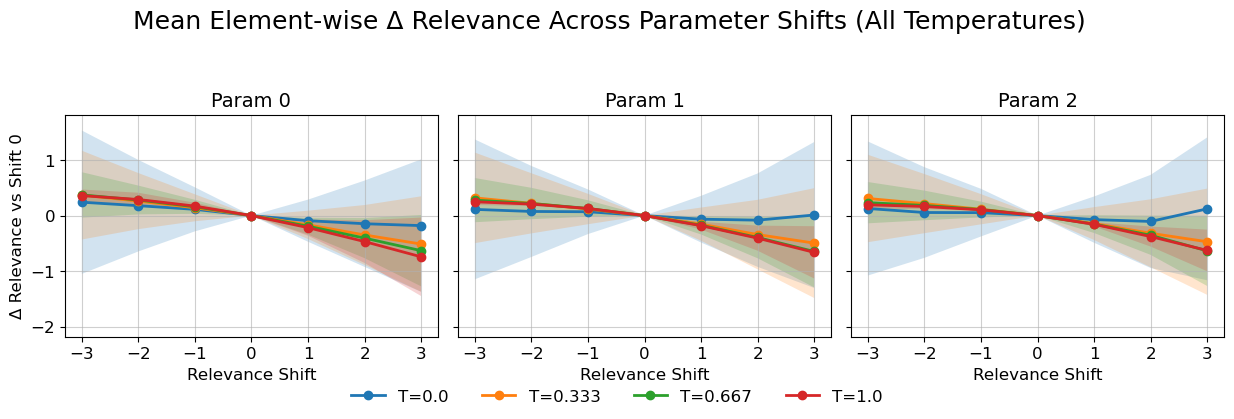

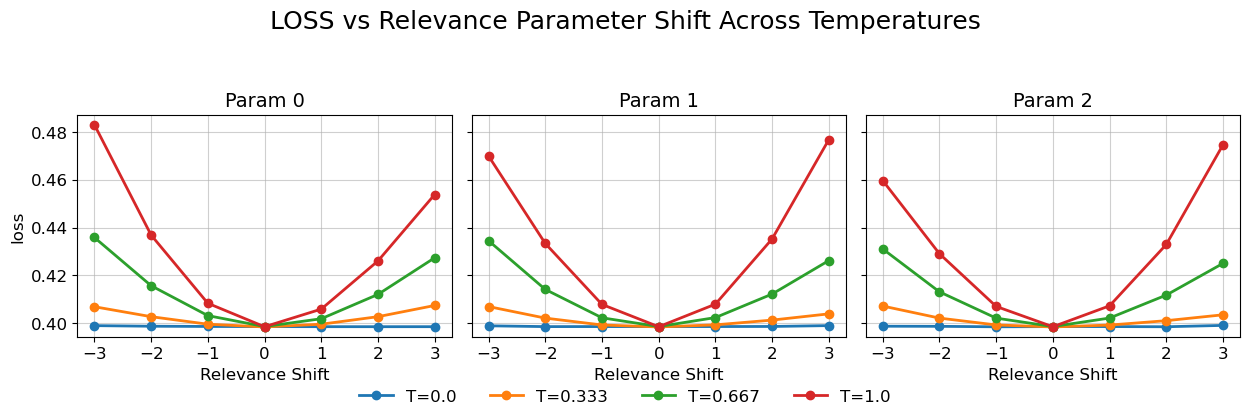

In [8]:
folder_path_test_deep = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.0,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_deep_0333 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.333,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_deep_0667 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=0.667,random_state=2021,relevance=deep,relevance_tower=deep'
folder_path_test_deep_1 = 'results/deterministic_custom_data/data=Custom_dataset,experiment=test,logging_policy_ranker=deep,logging_policy_sampler=e_greedy,policy_strength=1,policy_temperature=1.0,random_state=2021,relevance=deep,relevance_tower=deep'
multi_relevance_df_test_deep = load_and_concat_multi_shift_files(folder_path_test_deep, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_0333 = load_and_concat_multi_shift_files(folder_path_test_deep_0333, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_0667 = load_and_concat_multi_shift_files(folder_path_test_deep_0667, prefix, 'relevance_shift', 'param_idx')
multi_relevance_df_test_deep_1 = load_and_concat_multi_shift_files(folder_path_test_deep_1, prefix, 'relevance_shift', 'param_idx')
# get performance df
prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'
multi_performance_df_test_deep = load_and_concat_multi_shift_files(folder_path_test_deep, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_0333 = load_and_concat_multi_shift_files(folder_path_test_deep_0333, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_0667 = load_and_concat_multi_shift_files(folder_path_test_deep_0667, prefix_performance_clicks, 'relevance_shift', 'param_idx')
multi_performance_df_test_deep_1 = load_and_concat_multi_shift_files(folder_path_test_deep_1, prefix_performance_clicks, 'relevance_shift', 'param_idx') 

plot_mean_relevance_shift_all([multi_relevance_df_test_deep, multi_relevance_df_test_deep_0333, multi_relevance_df_test_deep_0667, multi_relevance_df_test_deep_1], [0.0, 0.333, 0.667, 1.0])
plot_performance_grid_all_temps([multi_performance_df_test_deep, multi_performance_df_test_deep_0333, multi_performance_df_test_deep_0667, multi_performance_df_test_deep_1], [0.0, 0.333, 0.667, 1.0], 'loss')

In [9]:

def plot_performance_combined(
    all_multi_performance_dfs,
    temperatures,
    doc_group_sizes,
    metric='loss',
    diff_from_zero=False
):
    """
    Plot performance metric (e.g., loss) vs relevance shift.
    - 4 subplots (one per temperature)
    - each subplot shows multiple lines (one per doc_group_size)
    - optional diff_from_zero to plot Δmetric relative to baseline (shift=0)
    """
    n_cols = len(temperatures)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=True)
    axes = np.array(axes).flatten()

    # iterate over temperatures (outer) and their respective dfs (inner = doc sizes)
    for ax, temp, dfs_for_temp in zip(axes, temperatures, all_multi_performance_dfs):
        all_y_values = []

        for docs, df in zip(doc_group_sizes, dfs_for_temp):
            if df is None or df.empty:
                continue

            param_idx = df['param_idx'].unique()[0]
            subset = df[df['param_idx'] == param_idx].sort_values('relevance_shift')

            if diff_from_zero:
                baseline = subset.loc[subset['relevance_shift'] == 0, metric].mean()
                y_values = subset[metric] - baseline
                label = f"{docs} Queries (Δ)"
            else:
                y_values = subset[metric]
                label = f"{docs} Docs"

            ax.plot(
                subset['relevance_shift'],
                y_values,
                marker='o',
                linewidth=2,
                label=label
            )
            all_y_values.extend(y_values)

        # axis setup
        if len(all_y_values) > 0:
            margin = np.std(all_y_values) * 1.1
            ax.set_ylim(min(all_y_values) - margin, max(all_y_values) + margin)

        ax.set_title(f"T = {temp}", fontsize=14)
        ax.set_xlabel('Relevance Shift', fontsize=12)
        ax.grid(True, alpha=0.6)

        if ax == axes[0]:
            ylabel = f"Δ {metric}" if diff_from_zero else metric
            ax.set_ylabel(ylabel, fontsize=12)

    # shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='lower center',
        fontsize=12,
        ncol=len(doc_group_sizes),
        frameon=False
    )

    # title
    title_metric = f"Δ {metric}" if diff_from_zero else metric
    fig.suptitle(
        f"{title_metric.upper()} vs Relevance Shift — Across Doc Group Sizes & Temperatures",
        fontsize=18,
        y=1.05
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

['test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx0.csv', 'test_clicks_param_shift_2.0_idx0.csv', 'test_clicks_param_shift_-3.0_idx0.csv', 'test_clicks_param_shift_1.0_idx0.csv', 'test_clicks_param_shift_-2.0_idx0.csv', 'test_clicks_param_shift_3.0_idx0.csv']
['test_relevance_param_shift_-3.0_idx0.csv', 'test_relevance_param_shift_1.0_idx0.csv', 'test_relevance_param_shift_3.0_idx0.csv', 'test_relevance_param_shift_-1.0_idx0.csv', 'test_relevance_param_shift_-2.0_idx0.csv', 'test_relevance_param_shift_0.0_idx0.csv', 'test_relevance_param_shift_2.0_idx0.csv']
['test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_-1.0_idx0.csv', 'test_clicks_param_shift_2.0_idx0.csv', 'test_clicks_param_shift_-3.0_idx0.csv', 'test_clicks_param_shift_1.0_idx0.csv', 'test_clicks_param_shift_-2.0_idx0.csv', 'test_clicks_param_shift_3.0_idx0.csv']
['test_relevance_param_shift_-3.0_idx0.csv', 'test_relevance_param_shift_1.0_idx0.csv', 'test_relevance_param_shift_3.0_idx0.cs

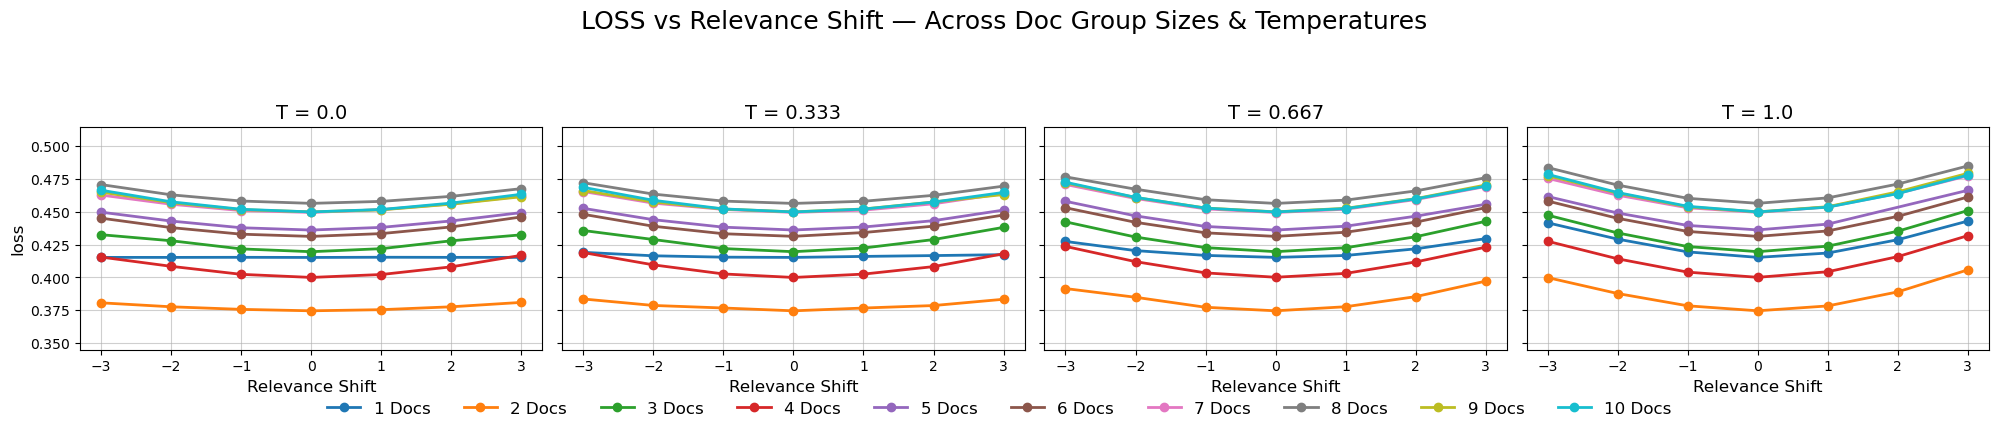

In [10]:

prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'

temperatures = [0.0, 0.333, 0.667, 1.0]
doc_group_sizes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

def make_folder_path(n_queries, temp):
    return (
        f"results/relevance_shift_overlap/data=Custom_dataset_deep,docs_per_group=10,experiment=test,"
        f"logging_policy_ranker=deep,logging_policy_sampler=e_greedy,"
        f"num_queries={n_queries},policy_strength=1,policy_temperature={temp},"
        f"random_state=2021,relevance=deep,relevance_tower=deep"
    )

# Containers for all results (now grouped by temperature)
all_multi_performance_dfs = []
all_multi_relevance_dfs = []

# Loop through temperatures first
for temp in temperatures:
    performance_list = []
    relevance_list = []

    for n_queries in doc_group_sizes:
        folder_path = make_folder_path(n_queries, temp)

        # Load performance (clicks)
        perf_df = load_and_concat_multi_shift_files(
            folder_path,
            prefix_performance_clicks,
            'relevance_shift',
            'param_idx'
        )

        # Load relevance
        rel_df = load_and_concat_multi_shift_files(
            folder_path,
            prefix_performance_relevance,
            'relevance_shift',
            'param_idx'
        )

        performance_list.append(perf_df)
        relevance_list.append(rel_df)

    # Append results for this temperature value
    all_multi_performance_dfs.append(performance_list)
    all_multi_relevance_dfs.append(relevance_list)

# ✅ Now you can plot, just reversing the meaning of the axes
# plot_mean_relevance_shift_combined(all_multi_relevance_dfs, doc_group_sizes, temperatures)
plot_performance_combined(all_multi_performance_dfs, temperatures, doc_group_sizes, metric='loss', diff_from_zero=False)

In [185]:
prefix_performance_clicks = 'test_clicks_param_shift_'
prefix_performance_relevance = 'test_relevance_param_shift_'
prefix_bias_param_shift = 'bias_param_shift_'
prefix_relevance_param_shift = 'predicted_relevance_param_shift_'

# now these represent s_doc values
s_doc_values = [-0.2, 0.3, 0.5, 1, 10]
policy_temperatures = [0, 0.0, 1.0]
doc_group_sizes = [1, 2, 3, 10, 20, 1000]

def make_folder_path(n_queries, s_doc, policy_temperature):
    return (
        f"results/deep_separated/"
        f"data=Custom_dataset_deep,docs_per_group=10,experiment=deep_separated,"
        f"logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,"
        f"num_queries={n_queries},policy_temperature={policy_temperature},"
        f"relevance=deep,relevance_tower=deep,s_doc={s_doc}"
    )

# Initialize final collectors
all_multi_performance_df = []
all_multi_relevance_df = []
all_multi_bias_df = []
all_multi_predicted_relevance_df = []

for s_doc in s_doc_values:
    for policy_temp in policy_temperatures:
        for n_queries in doc_group_sizes:
            folder_path = make_folder_path(n_queries, s_doc, policy_temp)
            print(f"📂 Loading data from: {folder_path}")

            # Load all types of data
            try:
                perf_df = load_and_concat_multi_shift_files(folder_path, prefix_performance_clicks, 'relevance_shift', 'param_idx')
                rel_df = load_and_concat_multi_shift_files(folder_path, prefix_performance_relevance, 'relevance_shift', 'param_idx')
                bias_df = load_and_concat_multi_shift_files(folder_path, prefix_bias_param_shift, 'relevance_shift', 'param_idx')
                pred_rel_df = load_and_concat_multi_shift_files(folder_path, prefix_relevance_param_shift, 'relevance_shift', 'param_idx')

                # Annotate metadata
                for df in [perf_df, rel_df, bias_df, pred_rel_df]:
                    df['s_doc'] = s_doc
                    df['policy_temperature'] = policy_temp
                    df['n_queries'] = n_queries

                # Append to master lists
                all_multi_performance_df.append(perf_df)
                all_multi_relevance_df.append(rel_df)
                all_multi_bias_df.append(bias_df)
                all_multi_predicted_relevance_df.append(pred_rel_df)
            except Exception as e:
                pass

# ✅ Concatenate everything into single DataFrames
all_multi_performance_df = pd.concat(all_multi_performance_df, ignore_index=True)
all_multi_relevance_df = pd.concat(all_multi_relevance_df, ignore_index=True)
all_multi_bias_df = pd.concat(all_multi_bias_df, ignore_index=True)
all_multi_predicted_relevance_df = pd.concat(all_multi_predicted_relevance_df, ignore_index=True)

print("✅ Aggregated data shapes:")
print("Performance:", all_multi_performance_df.shape)
print("Relevance:", all_multi_relevance_df.shape)
print("Bias:", all_multi_bias_df.shape)
print("Predicted Relevance:", all_multi_predicted_relevance_df.shape)


📂 Loading data from: results/deep_separated/data=Custom_dataset_deep,docs_per_group=10,experiment=deep_separated,logging_policy_ranker=ordered,logging_policy_sampler=e_greedy,num_queries=1,policy_temperature=0,relevance=deep,relevance_tower=deep,s_doc=-0.2
['test_clicks_param_shift_0.0_idx0.csv', 'test_clicks_param_shift_2.0_idx0.csv', 'test_clicks_param_shift_1.0_idx0.csv', 'test_clicks_param_shift_3.0_idx0.csv']
['test_relevance_param_shift_1.0_idx0.csv', 'test_relevance_param_shift_3.0_idx0.csv', 'test_relevance_param_shift_0.0_idx0.csv', 'test_relevance_param_shift_2.0_idx0.csv']
['bias_param_shift_0.0_idx0.csv', 'bias_param_shift_2.0_idx0.csv', 'bias_param_shift_1.0_idx0.csv', 'bias_param_shift_3.0_idx0.csv']
['predicted_relevance_param_shift_3.0_idx0.csv', 'predicted_relevance_param_shift_1.0_idx0.csv', 'predicted_relevance_param_shift_2.0_idx0.csv', 'predicted_relevance_param_shift_0.0_idx0.csv']
📂 Loading data from: results/deep_separated/data=Custom_dataset_deep,docs_per_group

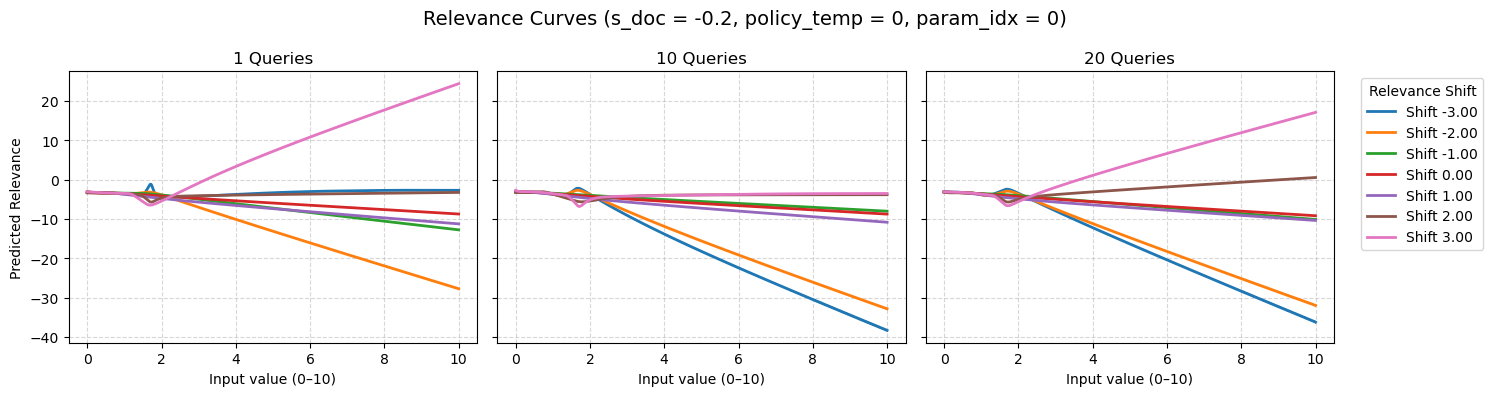

In [186]:
import matplotlib.pyplot as plt

# Filter down to the target conditions
df_plot = all_multi_predicted_relevance_df[
    (all_multi_predicted_relevance_df["policy_temperature"] == 0.0)
    & (all_multi_predicted_relevance_df["s_doc"] == -0.2)
    & (all_multi_predicted_relevance_df["param_idx"] == 0)
]

# Ensure sorting for smooth lines
df_plot = df_plot.sort_values(by=["n_queries", "relevance_shift", "input_value"])

# Prepare subplots for 3 query group sizes
query_values = [1, 10, 20]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, n_q in zip(axes, query_values):
    subset = df_plot[df_plot["n_queries"] == n_q]

    for rel_shift, group in subset.groupby("relevance_shift"):
        ax.plot(
            group["input_value"],
            group["relevance"],
            label=f"Shift {rel_shift:.2f}",
            linewidth=2
        )

    ax.set_title(f"{n_q} Queries", fontsize=12)
    ax.set_xlabel("Input value (0–10)")
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_ylabel("Predicted Relevance")
axes[-1].legend(title="Relevance Shift", bbox_to_anchor=(1.05, 1), loc="upper left")
fig.suptitle("Relevance Curves (s_doc = -0.2, policy_temp = 0, param_idx = 0)", fontsize=14)
plt.tight_layout()
plt.show()


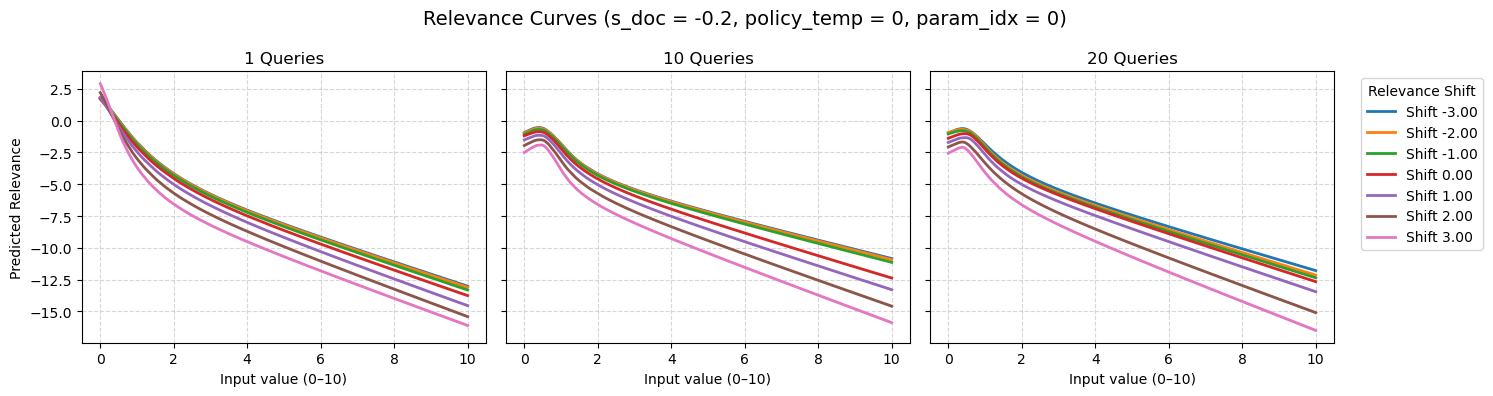

In [187]:
import matplotlib.pyplot as plt

# Filter down to the target conditions
df_plot = all_multi_predicted_relevance_df[
    (all_multi_predicted_relevance_df["policy_temperature"] == 1.0)
    & (all_multi_predicted_relevance_df["s_doc"] == 0.3)
    & (all_multi_predicted_relevance_df["param_idx"] == 0)
]

# Ensure sorting for smooth lines
df_plot = df_plot.sort_values(by=["n_queries", "relevance_shift", "input_value"])
# Prepare subplots for 3 query group sizes
query_values = [1, 10, 20]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, n_q in zip(axes, query_values):
    subset = df_plot[df_plot["n_queries"] == n_q]

    for rel_shift, group in subset.groupby("relevance_shift"):
        ax.plot(
            group["input_value"],
            group["relevance"],
            label=f"Shift {rel_shift:.2f}",
            linewidth=2
        )

    ax.set_title(f"{n_q} Queries", fontsize=12)
    ax.set_xlabel("Input value (0–10)")
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_ylabel("Predicted Relevance")
axes[-1].legend(title="Relevance Shift", bbox_to_anchor=(1.05, 1), loc="upper left")
fig.suptitle("Relevance Curves (s_doc = -0.2, policy_temp = 0, param_idx = 0)", fontsize=14)
plt.tight_layout()
plt.show()


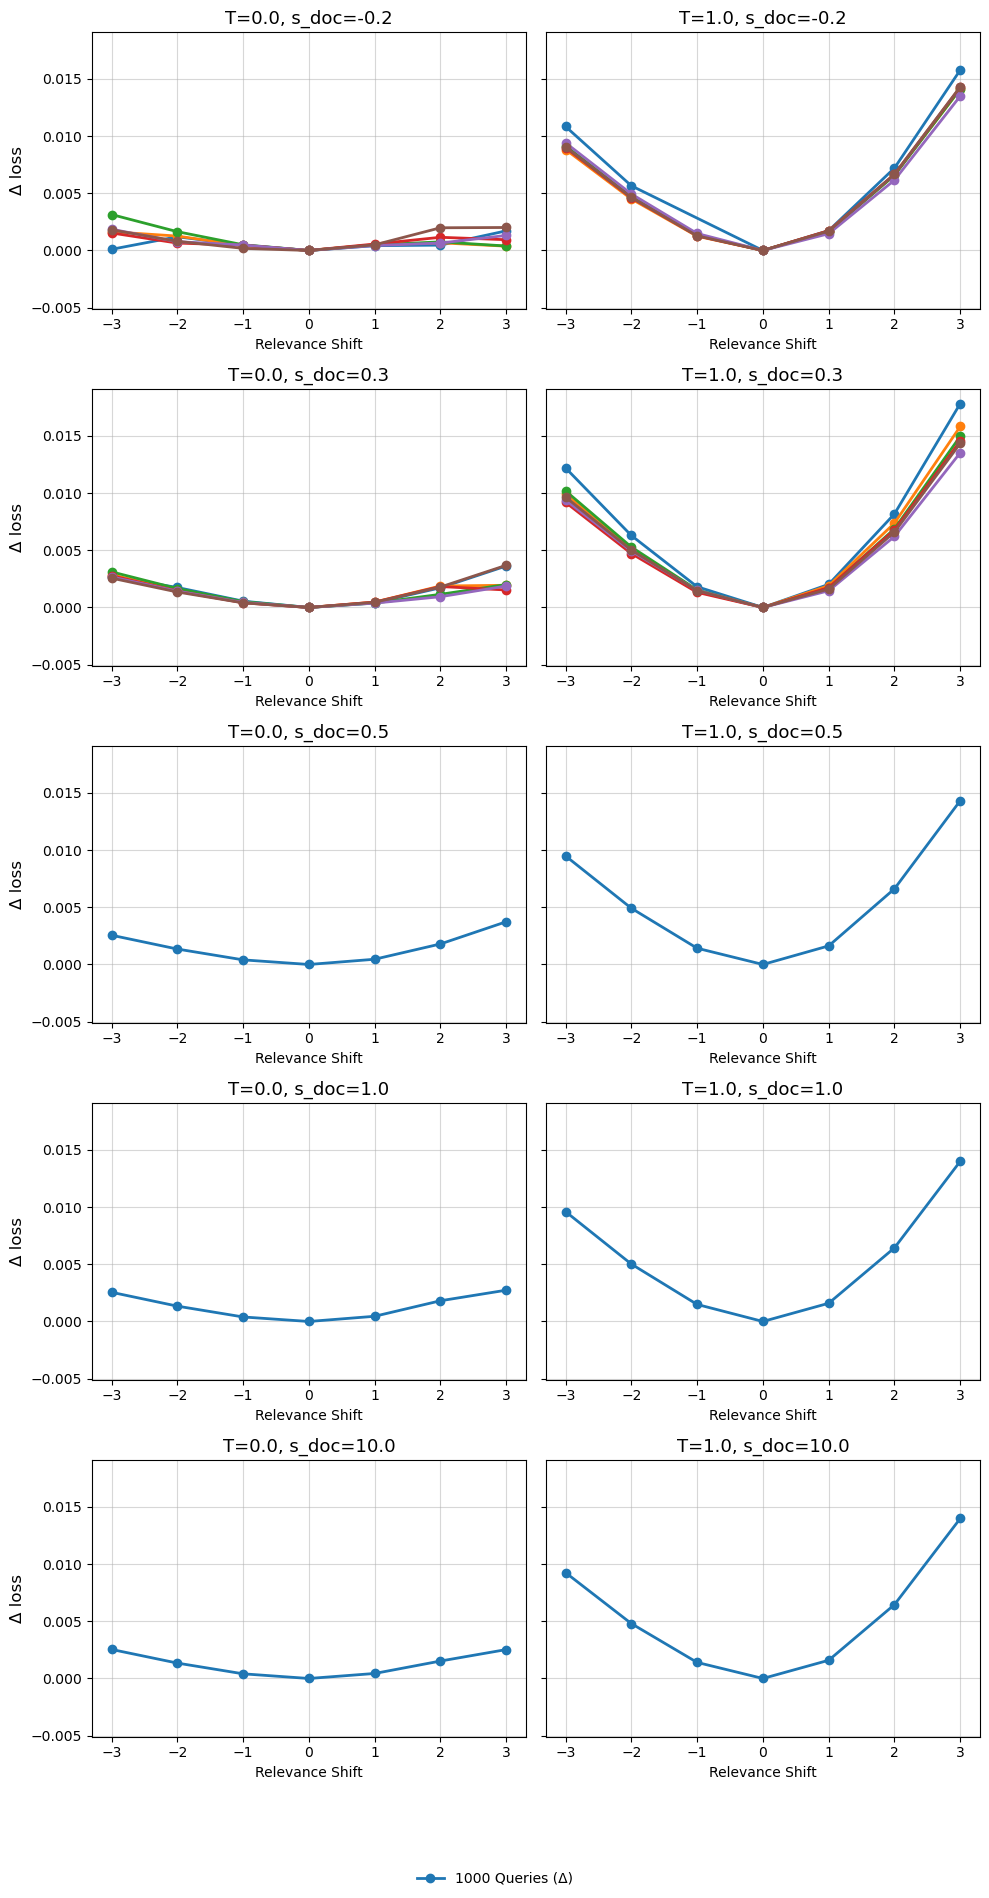

In [188]:

def plot_performance_combined(
    df,
    metric='loss',
    diff_from_zero=False
):
    """
    Plot performance (e.g. loss) vs relevance shift for different policy temperatures and query group sizes.
    Expects a single DataFrame with columns:
    ['relevance_shift', 'param_idx', 's_doc', 'policy_temperature', 'n_queries', metric]
    """
    # Ensure all required columns exist
    required_cols = {'relevance_shift', 'param_idx', 's_doc', 'policy_temperature', 'n_queries', metric}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame missing required columns: {required_cols - set(df.columns)}")

    temperatures = sorted(df['policy_temperature'].unique())
    s_docs = sorted(df['s_doc'].unique())
    n_queries_list = sorted(df['n_queries'].unique())

    n_cols = len(temperatures)
    n_rows = len(s_docs)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
    axes = np.atleast_2d(axes)

    for i, s_doc in enumerate(s_docs):
        for j, temp in enumerate(temperatures):
            ax = axes[i, j]
            subset = df[(df['s_doc'] == s_doc) & (df['policy_temperature'] == temp)]

            if subset.empty:
                continue

            all_y_values = []

            for n_q in n_queries_list:
                sub_q = subset[subset['n_queries'] == n_q].sort_values('relevance_shift')
                if sub_q.empty:
                    continue

                if diff_from_zero:
                    baseline = sub_q.loc[sub_q['relevance_shift'] == 0, metric].mean()
                    y_values = sub_q[metric] - baseline
                    label = f"{n_q} Queries (Δ)"
                else:
                    y_values = sub_q[metric]
                    label = f"{n_q} Queries"

                ax.plot(
                    sub_q['relevance_shift'],
                    y_values,
                    marker='o',
                    linewidth=2,
                    label=label
                )
                all_y_values.extend(y_values)

            if len(all_y_values) > 0:
                margin = np.std(all_y_values) * 1.1
                ax.set_ylim(min(all_y_values) - margin, max(all_y_values) + margin)

            ax.set_title(f"T={temp}, s_doc={s_doc}", fontsize=13)
            ax.set_xlabel("Relevance Shift")
            ax.grid(True, alpha=0.5)
            if j == 0:
                ylabel = f"Δ {metric}" if diff_from_zero else metric
                ax.set_ylabel(ylabel, fontsize=12)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(n_queries_list), frameon=False)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

plot_performance_combined(all_multi_performance_df, metric='loss', diff_from_zero=True)


In [189]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_deep_relevance_with_caps(
    num_queries=2,
    docs_per_group=10,
    s_doc=0.0,
    hidden_units=[32, 32, 32],
    noise=0.0,
    random_state=41,
    show_boundaries=True,
    show_fill=True,
    fill_cmap="tab10",
    point_cmap="tab10",
    seed=42,
    jitter=0.0,
    baseline_gap=0.1,
    cap_height=0.03,
    ax=None,                # <-- new optional axis argument
    figsize=(10, 6),       # used only when ax is None (function creates its own figure)
):
    """
    Same behavior as your original function but draws into the supplied `ax` if provided.
    Returns the axis that was used (useful for further customization).
    """
    rng = np.random.default_rng(seed)
    deep_relevance = DeepRelevance(hidden_units=hidden_units, random_state=random_state, noise=noise)

    scores, data, boundaries = generate_deep_score_and_features_overlap(
        num_queries=num_queries,
        num_groups=1,
        docs_per_group=docs_per_group,
        D=2,
        s_group=0.0,
        s_doc=s_doc,
        rng=rng,
        deep_model=deep_relevance,
    )

    doc_ids = np.array([d[2] for d in data])
    b_values = np.array([d[3][1] for d in data])

    # Smooth model curve
    a_plot = np.zeros_like(np.linspace(0, 10, 500))
    b_plot = np.linspace(0, 10, 500)
    X_plot = np.column_stack((a_plot, b_plot))
    y_plot = np.ravel(deep_relevance(X_plot))

    # Create axis if not given
    created_fig = None
    if ax is None:
        created_fig = plt.figure(figsize=figsize)
        ax = created_fig.add_subplot(111)

    # Colormaps (safely index)
    cmap_fill = plt.get_cmap(fill_cmap)
    cmap_point = plt.get_cmap(point_cmap)
    # fallback if colormap returns an object without .colors
    try:
        fill_colors = cmap_fill.colors
    except AttributeError:
        # generate colors by sampling the colormap
        fill_colors = [cmap_fill(i / max(1, docs_per_group - 1)) for i in range(docs_per_group)]
    try:
        point_colors = cmap_point.colors
    except AttributeError:
        point_colors = [cmap_point(i / max(1, docs_per_group - 1)) for i in range(docs_per_group)]

    fill_colors = fill_colors[:docs_per_group]
    point_colors = point_colors[:docs_per_group]

    # Compute mean boundaries across queries (safe access)
    mean_bounds = []
    for doc_idx in range(docs_per_group):
        lefts = [q_bounds[doc_idx][0] for q_bounds in boundaries]
        rights = [q_bounds[doc_idx][1] for q_bounds in boundaries]
        mean_bounds.append((np.mean(lefts), np.mean(rights)))

    # --- Fill and boundary lines ---
    if show_fill:
        for i, (left, right) in enumerate(mean_bounds):
            color = fill_colors[i % len(fill_colors)]
            ax.axvspan(left, right, color=color, alpha=0.25)
            baseline_y = -baseline_gap * i - 1
            shift = 0.05
            ax.hlines(y=baseline_y, xmin=left + shift, xmax=right - shift, color=color, linewidth=3, alpha=0.9)
            ax.vlines([left + shift, right - shift], baseline_y - cap_height, baseline_y + cap_height, color=color, linewidth=2, alpha=0.9)

    if show_boundaries:
        for i, (left, right) in enumerate(mean_bounds):
            color = fill_colors[i % len(fill_colors)]
            ax.axvline(x=left, color=color, linestyle='--', linewidth=1.3, alpha=0.9)
            ax.axvline(x=right, color=color, linestyle='--', linewidth=1.3, alpha=0.9)

    # --- Plot sampled points ---
    handles, labels = [], []
    for doc_idx in np.unique(doc_ids):
        mask = doc_ids == doc_idx
        color = point_colors[doc_idx % len(point_colors)]
        y_vals = scores[mask] + rng.normal(0, jitter, size=np.sum(mask))
        scatter = ax.scatter(
            b_values[mask],
            y_vals,
            color=color,
            s=90,
            edgecolor='black',
            linewidth=0.8,
            alpha=0.95,
            label=f"Rank {doc_idx}",
            zorder=4,
        )
        handles.append(scatter)
        labels.append(f"Rank {doc_idx}")

    # --- Add the main relevance curve last ---
    line, = ax.plot(b_plot, y_plot, color='black', lw=2, label='Deep relevance curve', zorder=5)
    handles.append(line)
    labels.append('Deep relevance curve')

    # --- Final formatting ---
    ax.set_xlabel('Feature b (second input dimension)', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xlim(0, 10)

    # Compute sensible ylim
    ymin = min(-baseline_gap * docs_per_group, np.min(y_plot) - 0.2)
    ymax = np.max(y_plot) + 0.2
    ax.set_ylim(ymin - 1, ymax)

    ax.grid(alpha=0.25)

    # Legend: place it outside if this is a small axis. Use small font.
    try:
        ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=min(6, len(labels)), fontsize=7, frameon=False)
    except Exception:
        # If legend placement fails, fall back to default
        ax.legend(handles, labels, fontsize=7, frameon=False)

    if created_fig is not None:
        created_fig.tight_layout()
        plt.show()   # preserve original behavior when user doesn't pass ax

    return ax


/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_11722/3967831365.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])  # leave room for both legends


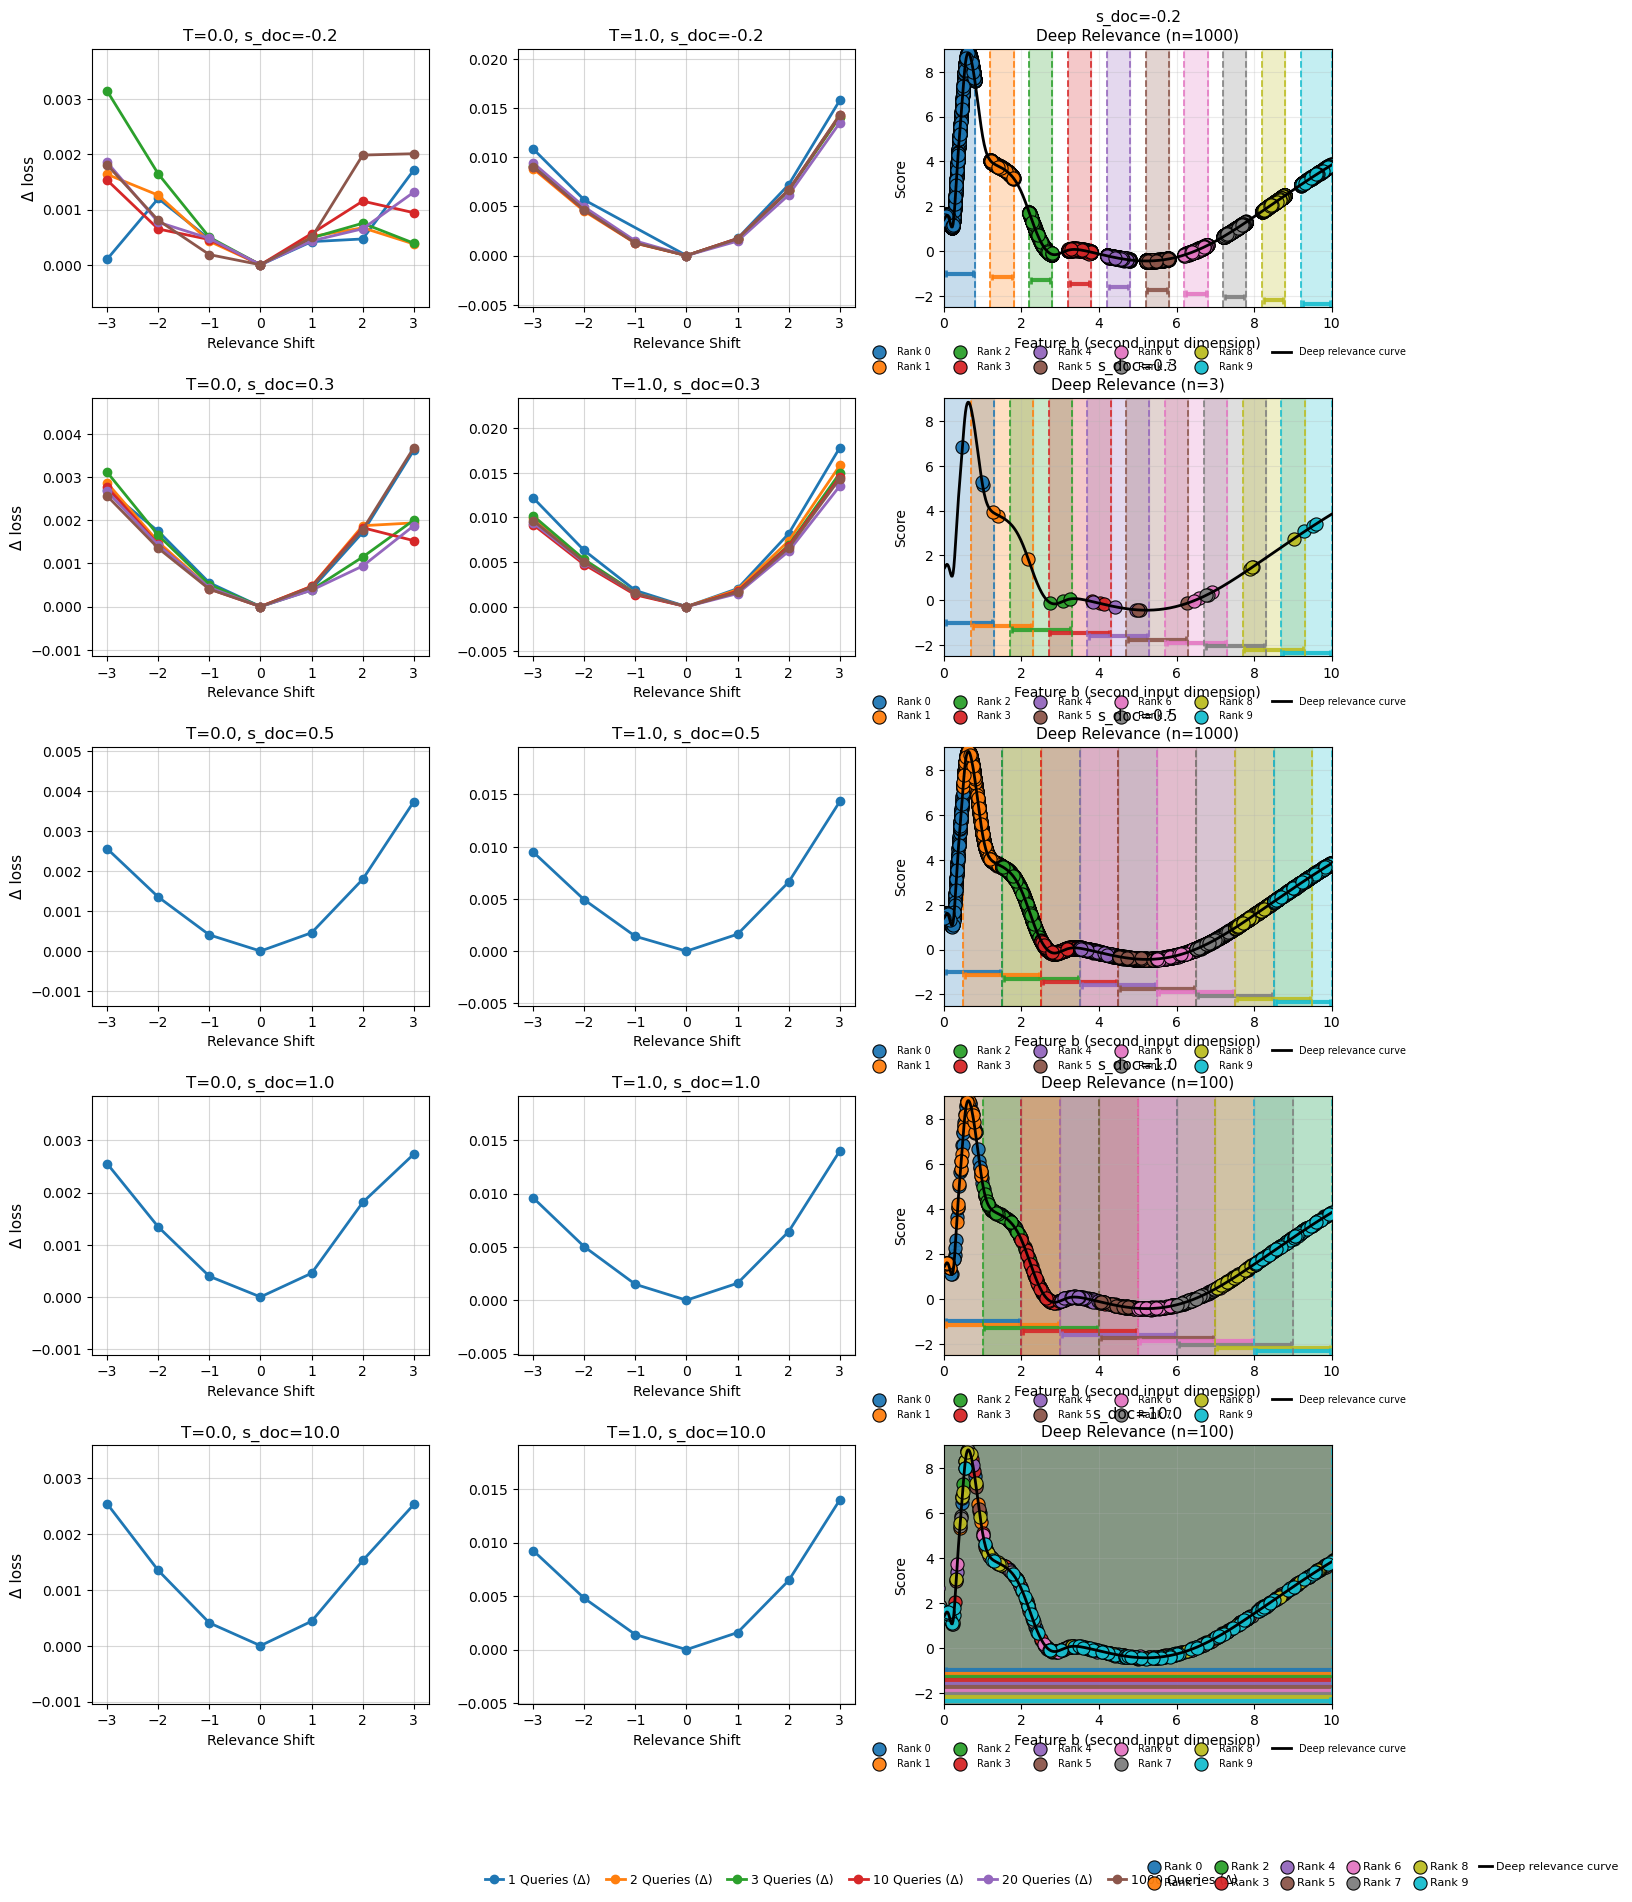

In [190]:
plot_performance_combined_with_relevance(all_multi_performance_df, metric='loss', diff_from_zero=True)


In [191]:

def plot_performance_row_with_relevance(
    df,
    s_doc,
    metric='loss',
    diff_from_zero=False,
    visualize_fn=None,
    num_queries_for_sdoc=None
):
    """
    Plot one row: performance vs relevance shift for a given s_doc,
    for all policy temperatures, plus the deep relevance visualization to the right.

    Creates separate legends for left and right plots (only once on the right).
    """
    if visualize_fn is None:
        visualize_fn = visualize_deep_relevance_with_caps

    # Default number of queries mapping
    if num_queries_for_sdoc is None:
        default_map = { -0.2: 1000, 0.3: 3, 0.5: 1000 }
        num_queries_for_sdoc = default_map.get(s_doc, 100)

    required_cols = {'relevance_shift', 'param_idx', 's_doc', 'policy_temperature', 'n_queries', metric}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame missing required columns: {required_cols - set(df.columns)}")

    temperatures = sorted(df['policy_temperature'].unique())
    n_queries_list = sorted(df['n_queries'].unique())
    n_cols = len(temperatures)

    # ---- Grid setup ----
    fig = plt.figure(figsize=(5 * (n_cols + 1.1), 4.5))
    gs = gridspec.GridSpec(
        1, n_cols + 1,
        width_ratios=[1]*n_cols + [1.1],
        wspace=0.25,
        figure=fig
    )

    left_axes = []
    left_legend_handles, left_legend_labels = None, None
    right_legend_handles, right_legend_labels = None, None

    # ---- Left subplots ----
    for j, temp in enumerate(temperatures):
        ax = fig.add_subplot(gs[0, j])
        left_axes.append(ax)

        subset = df[(df['s_doc'] == s_doc) & (df['policy_temperature'] == temp)]
        if subset.empty:
            ax.axis("off")
            continue

        all_y_values = []

        for n_q in n_queries_list:
            sub_q = subset[subset["n_queries"] == n_q].sort_values("relevance_shift")
            if sub_q.empty:
                continue

            if diff_from_zero:
                baseline_vals = sub_q.loc[sub_q["relevance_shift"] == 0, metric]
                if baseline_vals.empty:
                    idx_near = (sub_q["relevance_shift"] - 0).abs().idxmin()
                    baseline = sub_q.loc[idx_near, metric]
                else:
                    baseline = baseline_vals.mean()
                y_values = sub_q[metric] - baseline
                label = f"{n_q} Queries (Δ)"
            else:
                y_values = sub_q[metric]
                label = f"{n_q} Queries"

            ax.plot(
                sub_q["relevance_shift"],
                y_values,
                marker="o",
                linewidth=2,
                label=label,
            )
            all_y_values.extend(np.asarray(y_values).flatten().tolist())

        if len(all_y_values) > 0:
            margin = np.std(all_y_values) * 1.1 if np.std(all_y_values) > 0 else 0.1
            ax.set_ylim(min(all_y_values) - margin, max(all_y_values) + margin)

        ax.set_title(f"T={temp}, s_doc={s_doc}", fontsize=12)
        ax.set_xlabel("Relevance Shift")
        ax.grid(True, alpha=0.5)
        if j == 0:
            ylabel = f"Δ {metric}" if diff_from_zero else metric
            ax.set_ylabel(ylabel, fontsize=11)

        # Capture legend only once
        if left_legend_handles is None:
            h, l = ax.get_legend_handles_labels()
            if h:
                left_legend_handles, left_legend_labels = h, l

    # ---- Right subplot (deep relevance visualization) ----
    right_ax = fig.add_subplot(gs[0, -1])

    # Modified visualize function call – suppress its own legend internally
    visualize_fn(
        num_queries=num_queries_for_sdoc,
        docs_per_group=10,
        s_doc=s_doc,
        hidden_units=[32, 32, 32],
        noise=0.0,
        random_state=41,
        seed=42,
        fill_cmap="tab10",
        point_cmap="tab10",
        show_fill=True,
        show_boundaries=True,
        jitter=0.02,
        baseline_gap=0.15,
        cap_height=0.15,
        ax=right_ax,
    )

    # Remove any legend that the visualization might have added inside the axis
    right_ax.legend_.remove() if right_ax.get_legend() else None

    right_ax.set_title(f"s_doc={s_doc}\nDeep Relevance (n={num_queries_for_sdoc})", fontsize=11)

    # Capture legend handles manually from the plot content
    h, l = right_ax.get_legend_handles_labels()
    if h:
        right_legend_handles, right_legend_labels = h, l

    # ---- Shared legends ----
    fig.canvas.draw()
    left_bbox = np.array([ax.get_position().bounds for ax in left_axes])
    right_bbox = np.array([right_ax.get_position().bounds])

    left_xmin = left_bbox[:, 0].min()-0.5
    left_xmax = (left_bbox[:, 0] + left_bbox[:, 2]).max()
    right_xmin = right_bbox[:, 0].min()
    right_xmax = right_bbox[:, 0].max() + right_bbox[:, 0].max()

    # Left legend (centered below left plots)
    if left_legend_handles:
        fig.legend(
            left_legend_handles,
            left_legend_labels,
            loc="lower left",
            bbox_to_anchor=(left_xmin + (left_xmax - left_xmin)/2, -0.1),
            bbox_transform=fig.transFigure,
            frameon=False,
            fontsize=9,
            ncol=len(left_legend_labels),
            handlelength=1.5,
            columnspacing=1.2,
            handletextpad=0.4,
        )

    # Right legend (only once below right plot)
    if right_legend_handles:
        fig.legend(
            right_legend_handles,
            right_legend_labels,
            loc="lower left",
            bbox_to_anchor=(0.65, -0.1),
            bbox_transform=fig.transFigure,
            frameon=False,
            fontsize=8,
            ncol=min(6, len(right_legend_labels)),
            handlelength=1.2,
            columnspacing=1.0,
            handletextpad=0.3,
        )

    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()

In [192]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec

def plot_performance_row_with_relevance(
    df,
    s_doc,
    metric='loss',
    diff_from_zero=False,
    visualize_fn=None,
    num_queries_for_sdoc=None
):
    """
    Plot one row: performance vs relevance shift for a given s_doc,
    for all policy temperatures, plus the deep relevance visualization to the right.

    - Left plots share a common Y-axis.
    - Creates separate legends for left and right plots (only once on the right).
    """
    if visualize_fn is None:
        visualize_fn = visualize_deep_relevance_with_caps

    # Default number of queries mapping
    if num_queries_for_sdoc is None:
        default_map = { -0.2: 1000, 0.3: 3, 0.5: 1000 }
        num_queries_for_sdoc = default_map.get(s_doc, 100)

    required_cols = {'relevance_shift', 'param_idx', 's_doc', 'policy_temperature', 'n_queries', metric}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame missing required columns: {required_cols - set(df.columns)}")

    temperatures = sorted(df['policy_temperature'].unique())
    n_queries_list = sorted(df['n_queries'].unique())
    n_cols = len(temperatures)

    # ---- Grid setup ----
    fig = plt.figure(figsize=(5 * (n_cols + 1.1), 4.5))
    gs = gridspec.GridSpec(
        1, n_cols + 1,
        width_ratios=[1]*n_cols + [1.1],
        wspace=0.15,   # slightly tighter since shared y-axis
        figure=fig
    )

    left_axes = []
    left_legend_handles, left_legend_labels = None, None
    right_legend_handles, right_legend_labels = None, None
    all_y_values = []

    # ---- Left subplots ----
    first_ax = None
    for j, temp in enumerate(temperatures):
        # sharey only for non-first columns
        if j == 0:
            ax = fig.add_subplot(gs[0, j])
            first_ax = ax
        else:
            ax = fig.add_subplot(gs[0, j], sharey=first_ax)

        left_axes.append(ax)

        subset = df[(df['s_doc'] == s_doc) & (df['policy_temperature'] == temp)]
        if subset.empty:
            ax.axis("off")
            continue

        local_y = []

        for n_q in n_queries_list:
            sub_q = subset[subset["n_queries"] == n_q].sort_values("relevance_shift")
            if sub_q.empty:
                continue

            if diff_from_zero:
                baseline_vals = sub_q.loc[sub_q["relevance_shift"] == 0, metric]
                if baseline_vals.empty:
                    idx_near = (sub_q["relevance_shift"] - 0).abs().idxmin()
                    baseline = sub_q.loc[idx_near, metric]
                else:
                    baseline = baseline_vals.mean()
                y_values = sub_q[metric] - baseline
                label = f"{n_q} Queries (Δ)"
            else:
                y_values = sub_q[metric]
                label = f"{n_q} Queries"

            ax.plot(
                sub_q["relevance_shift"],
                y_values,
                marker="o",
                linewidth=2,
                label=label,
            )
            local_y.extend(np.asarray(y_values).flatten().tolist())

        if len(local_y) > 0:
            all_y_values.extend(local_y)

        ax.set_title(f"T={temp}, s_doc={s_doc}", fontsize=12)
        ax.set_xlabel("Relevance Shift")
        ax.grid(True, alpha=0.5)
        if j == 0:
            ylabel = f"Δ {metric}" if diff_from_zero else metric
            ax.set_ylabel(ylabel, fontsize=11)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)  # hide duplicate tick labels

        # Capture legend only once
        if left_legend_handles is None:
            h, l = ax.get_legend_handles_labels()
            if h:
                left_legend_handles, left_legend_labels = h, l

    # After plotting all left subplots, set shared y-limits
    if len(all_y_values) > 0:
        margin = np.std(all_y_values) * 1.1 if np.std(all_y_values) > 0 else 0.1
        ymin, ymax = min(all_y_values) - margin, max(all_y_values) + margin
        first_ax.set_ylim(ymin, ymax)

    # ---- Right subplot (deep relevance visualization) ----
    right_ax = fig.add_subplot(gs[0, -1])

    visualize_fn(
        num_queries=num_queries_for_sdoc,
        docs_per_group=10,
        s_doc=s_doc,
        hidden_units=[32, 32, 32],
        noise=0.0,
        random_state=41,
        seed=42,
        fill_cmap="tab10",
        point_cmap="tab10",
        show_fill=True,
        show_boundaries=True,
        jitter=0.02,
        baseline_gap=0.15,
        cap_height=0.15,
        ax=right_ax,
    )

    # Remove legend inside right plot (keep shared one)
    if right_ax.get_legend():
        right_ax.legend_.remove()

    right_ax.set_title(f"s_doc={s_doc}, ({num_queries_for_sdoc} sampled queries)", fontsize=11)

    # Capture handles (optional)
    h, l = right_ax.get_legend_handles_labels()
    if h:
        right_legend_handles, right_legend_labels = h, l

    # ---- Shared legends ----
    fig.canvas.draw()
    left_bbox = np.array([ax.get_position().bounds for ax in left_axes])
    right_bbox = np.array([right_ax.get_position().bounds])


    left_xmin = left_bbox[:, 0].min()-0.5
    left_xmax = (left_bbox[:, 0] + left_bbox[:, 2]).max()
    right_xmin = right_bbox[:, 0].min()
    right_xmax = right_bbox[:, 0].max() + right_bbox[:, 0].max()

    # Left legend (centered below left plots)
    if left_legend_handles:
        fig.legend(
            left_legend_handles,
            left_legend_labels,
            loc="lower left",
            bbox_to_anchor=(left_xmin + (left_xmax - left_xmin)/2, -0.1),
            bbox_transform=fig.transFigure,
            frameon=False,
            fontsize=9,
            ncol=len(left_legend_labels),
            handlelength=1.5,
            columnspacing=1.2,
            handletextpad=0.4,
        )

    # Right legend (only once below right plot)
    if right_legend_handles:
        fig.legend(
            right_legend_handles,
            right_legend_labels,
            loc="lower left",
            bbox_to_anchor=(0.62, -0.1),
            bbox_transform=fig.transFigure,
            frameon=False,
            fontsize=8,
            ncol=min(6, len(right_legend_labels)),
            handlelength=1.2,
            columnspacing=1.0,
            handletextpad=0.3,
        )
    

    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()


/var/folders/nb/j_h4xjxd1tl7g7169hm8cdnc0000gn/T/ipykernel_11722/1115959162.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])


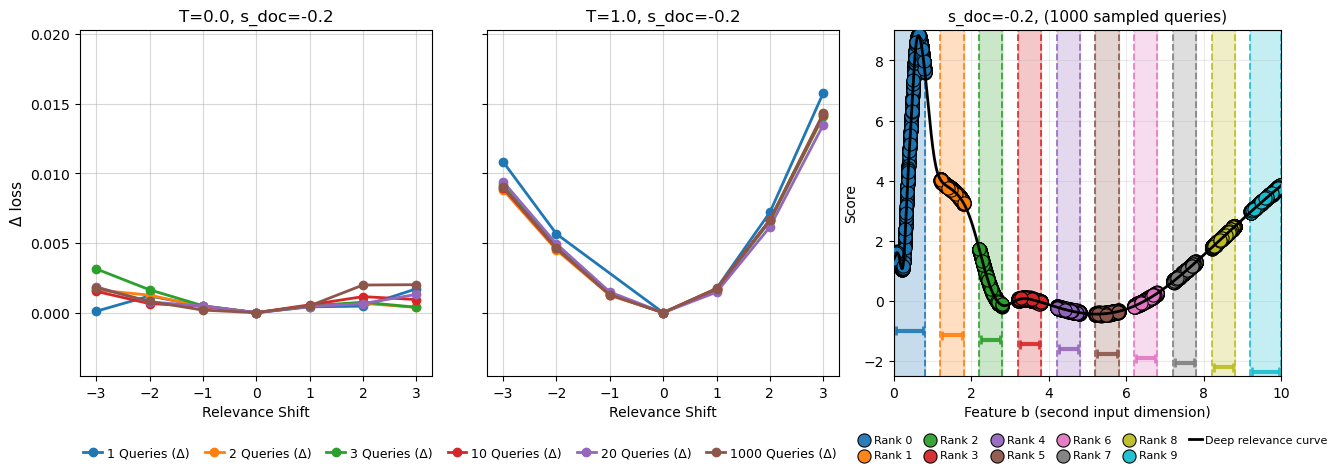

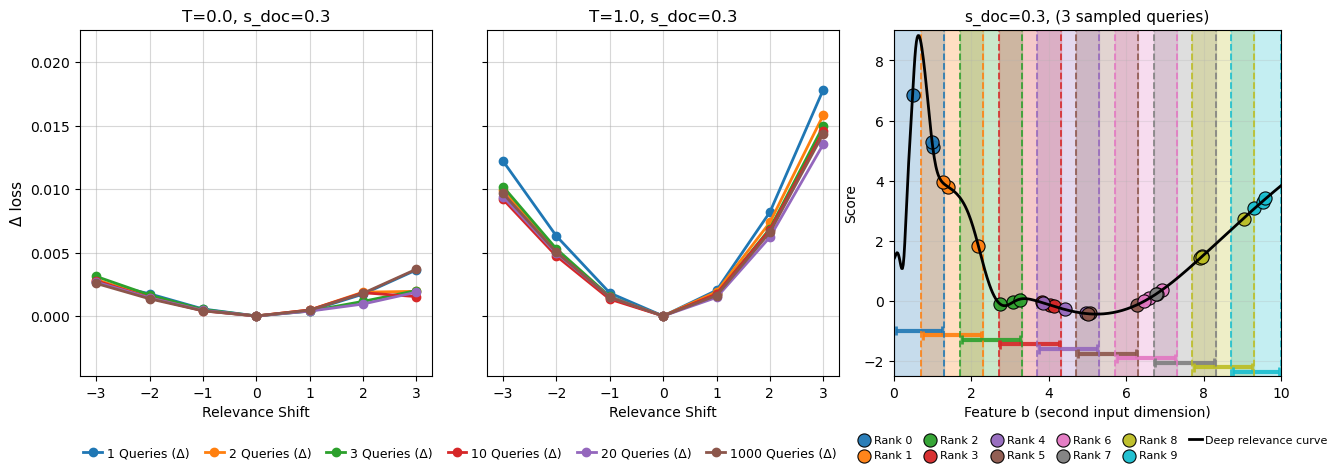

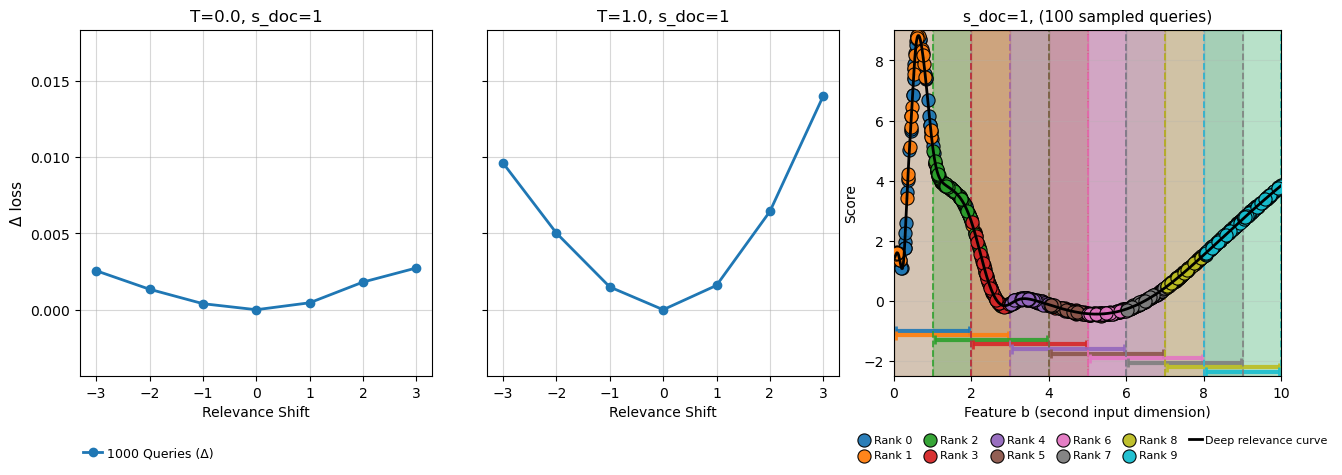

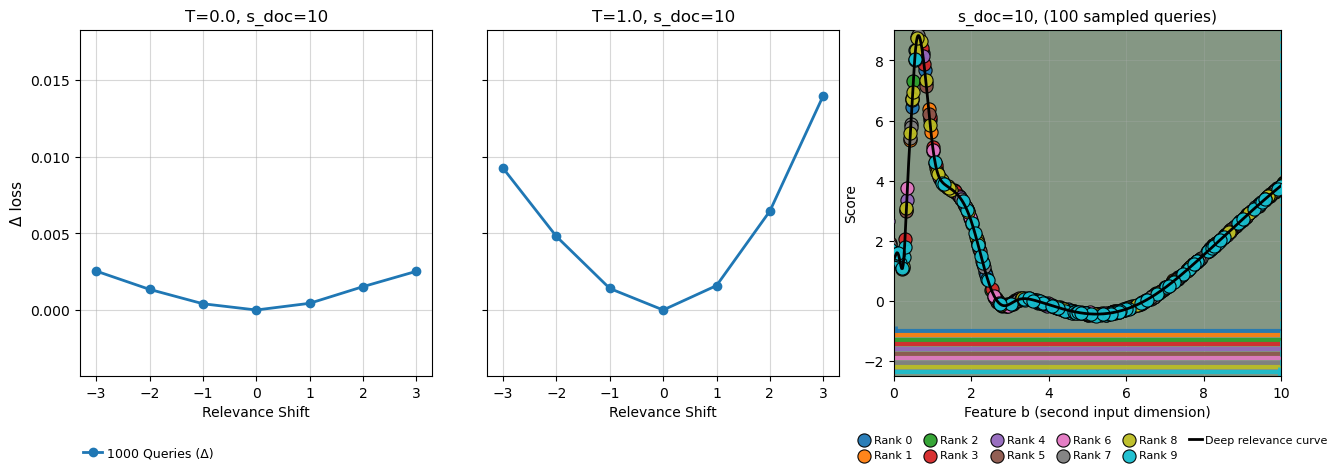

In [194]:
plot_performance_row_with_relevance(all_multi_performance_df, s_doc=-0.2, metric='loss', diff_from_zero=True)
plot_performance_row_with_relevance(all_multi_performance_df, s_doc=0.3, metric='loss', diff_from_zero=True)
plot_performance_row_with_relevance(all_multi_performance_df, s_doc=1, metric='loss', diff_from_zero=True)
plot_performance_row_with_relevance(all_multi_performance_df, s_doc=10, metric='loss', diff_from_zero=True)